# Week 1 — The hypothesis-testing agent (JAX, advanced stream)

The same Week 1 material, vectorised. This is the advanced stream: it exists
where doing many of something at once buys a genuinely different picture, not
merely a faster version of the same one.

Two places that applies this week:

- **Posteriors over a whole grid of priors at once**, so you can see the
  decision boundary of an inference problem rather than one posterior.
- **Ten thousand homeostasis runs in parallel**, so you get a survival
  *distribution* rather than a trajectory.

On Colab: `!pip install -q jax jaxlib` is usually unnecessary, JAX ships preinstalled.

In [1]:
import jax
import jax.numpy as jnp
from jax import vmap, jit, random
import numpy as np
import matplotlib.pyplot as plt

print('jax', jax.__version__, '| devices:', jax.devices())

jax 0.6.2 | devices: [CpuDevice(id=0)]


## 1. Every posterior at once

`vmap` turns a function written for one prior into one that handles a grid of
them, with no loop and no reshaping by hand.

In [2]:
A = jnp.array([[0.70, 0.15, 0.02],
               [0.25, 0.75, 0.08],
               [0.05, 0.10, 0.90]])

def posterior(prior, o):
    un = A[o] * prior
    ev = un.sum()
    return un / ev, ev

# a grid over the (leopard, baboon) simplex; 'nothing' takes up the slack
g = jnp.linspace(0.01, 0.60, 220)
L, B = jnp.meshgrid(g, g, indexing='ij')
valid = (L + B) < 0.98
priors = jnp.stack([L, B, 1 - L - B], axis=-1).reshape(-1, 3)

post, ev = jit(vmap(posterior, in_axes=(0, None)))(priors, 0)   # observe tawny flash
p_leopard = post[:, 0].reshape(L.shape)
print('grid of', priors.shape[0], 'posteriors computed in one call')

grid of 48400 posteriors computed in one call


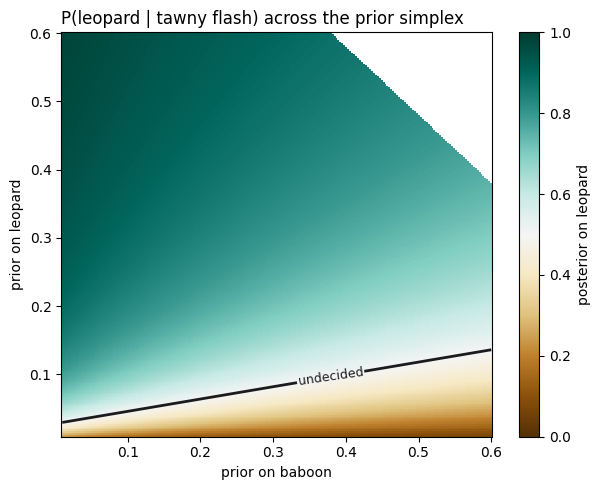

The black contour is the tipping point from the problems page.
At a baboon prior of 0.22 it crosses the leopard prior at about 0.068.


In [3]:
fig, ax = plt.subplots(figsize=(6.2, 5))
masked = jnp.where(valid, p_leopard, jnp.nan)
im = ax.pcolormesh(np.array(B), np.array(L), np.array(masked),
                   cmap='BrBG', vmin=0, vmax=1, shading='auto')
cs = ax.contour(np.array(B), np.array(L), np.array(masked),
                levels=[0.5], colors='#1b1b1e', linewidths=2)
ax.clabel(cs, fmt={0.5: 'undecided'}, fontsize=9)
ax.set_xlabel('prior on baboon'); ax.set_ylabel('prior on leopard')
ax.set_title('P(leopard | tawny flash) across the prior simplex', loc='left')
fig.colorbar(im, ax=ax, label='posterior on leopard')
plt.tight_layout(); plt.show()

print('The black contour is the tipping point from the problems page.')
print('At a baboon prior of 0.22 it crosses the leopard prior at about 0.068.')

## 2. Ten thousand lives at once

One trajectory tells you an anecdote. `vmap` over the random key gives you the
survival distribution, which is the thing the theory actually makes claims about.

In [4]:
@jit
def survive(key, sigma, kappa, steps=20000):
    """Return the step at which the walk leaves the unit disc, or `steps`."""
    noise = random.normal(key, (steps, 2)) * sigma

    def step(carry, inp):
        x, done, t = carry
        eps, i = inp
        x_new = jnp.where(done, x, x * (1 - kappa) + eps)
        out = (x_new @ x_new) > 1.0
        newly = out & (~done)
        t_new = jnp.where(newly, i, t)
        return (x_new, done | out, t_new), None

    idx = jnp.arange(steps)
    (_, died, t_death), _ = jax.lax.scan(
        step, (jnp.zeros(2), False, jnp.int32(steps)), (noise, idx))
    return t_death

keys = random.split(random.PRNGKey(0), 10000)
lifetimes = jit(vmap(survive, in_axes=(0, None, None)))(keys, 0.035, 0.0)
lifetimes = np.array(lifetimes)
print(f'10,000 unregulated lives: median {np.median(lifetimes):.0f} steps, '
      f'mean {lifetimes.mean():.0f}, max {lifetimes.max()}')

10,000 unregulated lives: median 342 steps, mean 431, max 3200


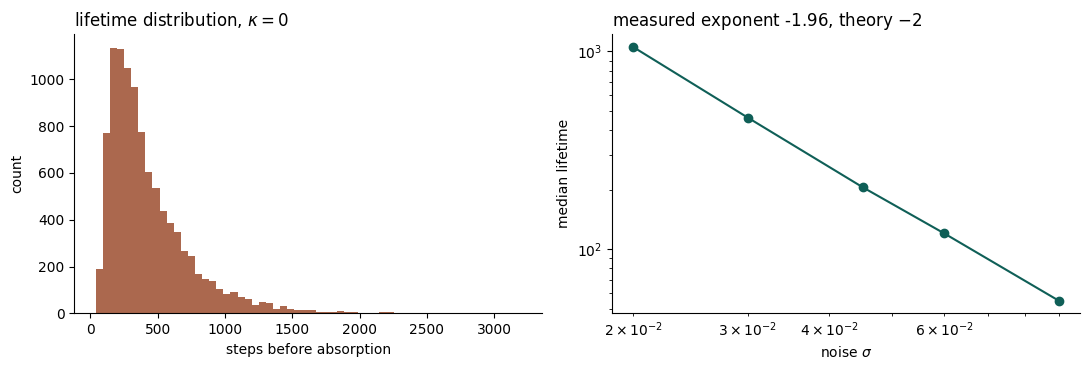

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(lifetimes, bins=60, color='#9c4d2f', alpha=0.85)
axes[0].set_xlabel('steps before absorption'); axes[0].set_ylabel('count')
axes[0].set_title('lifetime distribution, $\\kappa=0$', loc='left')

# the scaling law, measured rather than argued
sigmas = np.array([0.02, 0.03, 0.045, 0.06, 0.09])
med = []
for s in sigmas:
    lt = np.array(jit(vmap(survive, in_axes=(0, None, None)))(keys[:2000], float(s), 0.0))
    med.append(np.median(lt))
med = np.array(med)
slope = np.polyfit(np.log(sigmas), np.log(med), 1)[0]
axes[1].loglog(sigmas, med, 'o-', color='#0f5f57')
axes[1].set_xlabel('noise $\\sigma$'); axes[1].set_ylabel('median lifetime')
axes[1].set_title(f'measured exponent {slope:.2f}, theory $-2$', loc='left')

for a in axes: a.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

In [6]:
# and with action. The interesting range is far smaller than you would guess.
print('kappa   survived 20,000 steps   median lifetime')
for kappa in (0.0, 0.0005, 0.001, 0.002, 0.004, 0.008, 0.02):
    lt = np.array(jit(vmap(survive, in_axes=(0, None, None)))(keys[:3000], 0.035, float(kappa)))
    frac = (lt >= 20000).mean()
    med = np.median(lt)
    print(f'{kappa:<7.4f} {frac*100:>16.1f}%   {med:>14.0f}')

kappa   survived 20,000 steps   median lifetime


0.0000               0.0%              337


0.0005               0.0%              370


0.0010               0.0%              412


0.0020               0.0%              540


0.0040               0.0%             1021


0.0080              12.6%             6582


0.0200              99.9%            20000


That last table is the whole of Lesson 1 in four numbers. The physics did not
change and the noise did not change. What changed is that the system began to
move in a way that depends on where it is.

## Over to you

1. Sweep `kappa` finely between 0 and 0.05 and find where survival probability
   crosses one half. Is the transition sharp?
2. `survive` currently keeps integrating after death and masks the result. Rewrite
   it with `jax.lax.while_loop` to stop early. Is it faster? Why might it not be,
   under `vmap`?
3. Vectorise the *ambiguity* sweep from the NumPy notebook over both `lambda` and
   the prior at once, and plot information gained as a surface.